<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Normalization Techniques**


Estimated time needed: **30** minutes


In this lab, you will focus on data normalization. This includes identifying compensation-related columns, applying normalization techniques, and visualizing the data distributions.


## Objectives


In this lab, you will perform the following:


- Identify duplicate rows and remove them.

- Check and handle missing values in key columns.

- Identify and normalize compensation-related columns.

- Visualize the effect of normalization techniques on data distributions.


-----


## Hands on Lab


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### Step 2: Load the Dataset into a DataFrame


We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.


The functions below will download the dataset into your browser:


In [2]:
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

df = pd.read_csv("../data/data.csv")

# Display the first few rows to check if data is loaded correctly
df.head()


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,0,0,0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,2,2,2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,3,3,3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,4,4,4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [3]:
#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv")

In [4]:
# df.to_csv("data.csv")

### Section 1: Handling Duplicates
##### Task 1: Identify and remove duplicate rows.


In [5]:
## Write your code here
df = df.drop_duplicates(subset="ResponseId")
df.duplicated().sum()

np.int64(0)

### Section 2: Handling Missing Values
##### Task 2: Identify missing values in `CodingActivities`.


In [6]:
## Write your code here
df.CodingActivities.isna().sum()

np.int64(10971)

##### Task 3: Impute missing values in CodingActivities with forward-fill.


In [7]:
## Write your code here
df['CodingActivities'] = df['CodingActivities'].ffill()
df.CodingActivities.isna().sum()

np.int64(0)

**Note**:  Before normalizing ConvertedCompYearly, ensure that any missing values (NaN) in this column are handled appropriately. You can choose to either drop the rows containing NaN or replace the missing values with a suitable statistic (e.g., median or mean).


In [8]:
df.ConvertedCompYearly.isna().sum()

np.int64(42002)

### Section 3: Normalizing Compensation Data
##### Task 4: Identify compensation-related columns, such as ConvertedCompYearly.
Normalization is commonly applied to compensation data to bring values within a comparable range. Here, you’ll identify ConvertedCompYearly or similar columns, which contain compensation information. This column will be used in the subsequent tasks for normalization.


In [9]:
## Write your code here
comp = []
for col in df.columns:
	if "Comp" in col:
		comp.append(col)
comp

['CompTotal', 'AIComplex', 'ConvertedCompYearly']

##### Task 5: Normalize ConvertedCompYearly using Min-Max Scaling.
Min-Max Scaling brings all values in a column to a 0-1 range, making it useful for comparing data across different scales. Here, you will apply Min-Max normalization to the ConvertedCompYearly column, creating a new column ConvertedCompYearly_MinMax with normalized values.


In [10]:
# df = df.fillna({"ConvertedCompYearly" : df.ConvertedCompYearly.median()})

In [11]:
df.ConvertedCompYearly.isna().sum()

np.int64(42002)

In [12]:
# Eliminating extreme outliers
df = df.loc[df.ConvertedCompYearly < df.ConvertedCompYearly.quantile(0.95, interpolation="linear")]

In [13]:
## Write your code here
min = df.ConvertedCompYearly.min()
max = df.ConvertedCompYearly.max()
df["ConvertedCompYearly_MinMax"] = (df.ConvertedCompYearly - min) / (max - min)
df.ConvertedCompYearly_MinMax.value_counts().reset_index().sort_values("ConvertedCompYearly_MinMax")

,ConvertedCompYearly_MinMax,count
213,0.000000,16
712,0.000005,5
644,0.000010,5
757,0.000014,4
691,0.000019,5
...,...,...
2240,0.991813,1
2111,0.991908,1
685,0.993523,5
774,0.998300,4


##### Task 6: Apply Z-score Normalization to `ConvertedCompYearly`.

Z-score normalization standardizes values by converting them to a distribution with a mean of 0 and a standard deviation of 1. This method is helpful for datasets with a Gaussian (normal) distribution. Here, you’ll calculate Z-scores for the ConvertedCompYearly column, saving the results in a new column ConvertedCompYearly_Zscore.


In [14]:
## Write your code here
mean = df.ConvertedCompYearly.mean()
std = df.ConvertedCompYearly.std()

df["ConvertedCompYearly_Zscore"] = (df.ConvertedCompYearly - mean) / std
df["ConvertedCompYearly_Zscore"].value_counts().reset_index().sort_values("ConvertedCompYearly_Zscore", ascending=False)

,ConvertedCompYearly_Zscore,count
5368,2.816428,1
774,2.809236,4
685,2.789034,5
2111,2.782206,1
2240,2.781802,1
...,...,...
691,-1.412796,5
757,-1.412816,4
644,-1.412837,5
712,-1.412857,5


### Section 4: Visualization of Normalized Data
##### Task 7: Visualize the distribution of `ConvertedCompYearly`, `ConvertedCompYearly_Normalized`, and `ConvertedCompYearly_Zscore`

Visualization helps you understand how normalization changes the data distribution. In this task, create histograms for the original ConvertedCompYearly, as well as its normalized versions (ConvertedCompYearly_MinMax and ConvertedCompYearly_Zscore). This will help you compare how each normalization technique affects the data range and distribution.


In [15]:
# df_z = df[df["ConvertedCompYearly_Zscore"].abs() < 2]

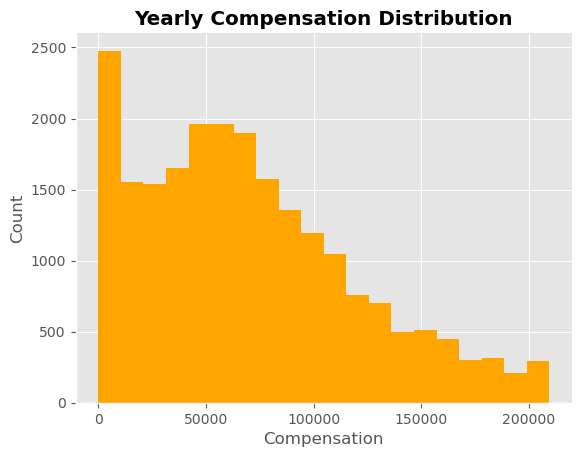

In [16]:
plt.style.use("ggplot")
plt.rc("axes.spines", top=False, right=False)

plt.hist(df["ConvertedCompYearly"], bins=20, color="orange")
plt.xlabel("Compensation")
plt.title("Yearly Compensation Distribution", weight=750)
plt.ylabel("Count")
plt.savefig("Comp.png");

In [17]:
df.loc[df["ConvertedCompYearly"] <= 10000, "Age"].value_counts()

Age
25-34 years old       1070
18-24 years old        898
35-44 years old        319
45-54 years old         75
Under 18 years old      38
55-64 years old         16
65 years or older        1
Name: count, dtype: int64

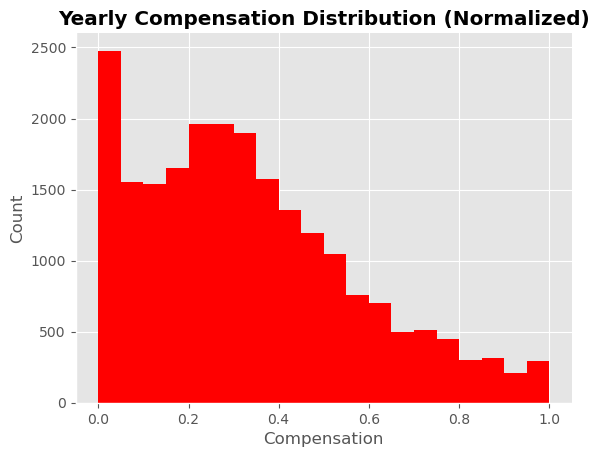

In [18]:
plt.hist(df["ConvertedCompYearly_MinMax"], bins=20, color="red")
plt.xlabel("Compensation")
plt.title("Yearly Compensation Distribution (Normalized)", weight=750)
plt.ylabel("Count");

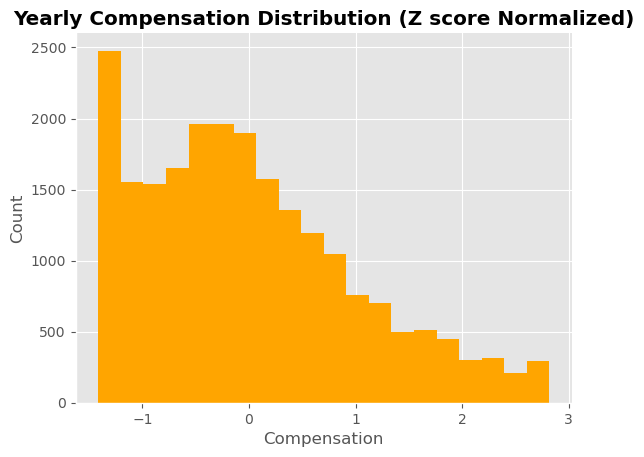

In [19]:
## Write your code here
# df = df[df["ConvertedCompYearly_Zscore"].abs() < 2]
plt.hist(df["ConvertedCompYearly_Zscore"], bins=20, color="orange")
plt.xlabel("Compensation")
plt.title("Yearly Compensation Distribution (Z score Normalized)", weight=750)
plt.ylabel("Count");

### Summary


In this lab, you practiced essential normalization techniques, including:

- Identifying and handling duplicate rows.

- Checking for and imputing missing values.

- Applying Min-Max scaling and Z-score normalization to compensation data.

- Visualizing the impact of normalization on data distribution.


Copyright © IBM Corporation. All rights reserved.
